# \publihebdos usage long-tail

Loads `usage_summary_daj.csv` (overall + per-month usage count per template),
keeps only the `total` column, reorders templates by decreasing usage, and
plots the resulting long-tail distribution referenced in
`chapters/definitions/main.tex` (`fig:publihebdos-usage-longtail`).

Run with: `pip install pandas matplotlib && jupyter nbconvert --to notebook --execute generate_usage_longtail.ipynb`
(or just run the cells interactively).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("usage_summary_daj.csv", sep=";")
df = df.dropna(subset=["total"])
df = df[["total"]].sort_values("total", ascending=False).reset_index(drop=True)
df["rank"] = range(1, len(df) + 1)
df.head()

,total,rank
0,38005,1
1,30561,2
2,30191,3
3,25535,4
4,23949,5


In [3]:
# Empirical short-head / long-tail cutoff already reported in the thesis text
# (chapters/definitions/main.tex, sec:publihebdos): usage above 8000.
THRESHOLD = 8000
head_count = int((df["total"] > THRESHOLD).sum())
head_pct = 100 * head_count / len(df)
print(f"{head_count} templates ({head_pct:.1f}% of the catalog) have usage above {THRESHOLD}")

10 templates (1.3% of the catalog) have usage above 8000


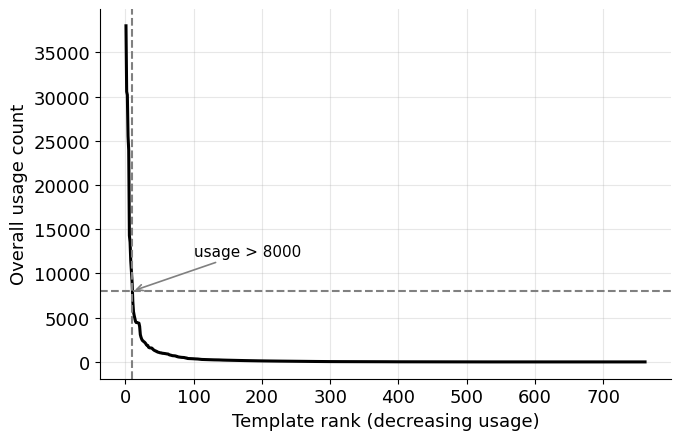

In [7]:
plt.rcParams.update({"font.size": 13, "axes.titlesize": 13, "legend.fontsize": 11})
fig, ax = plt.subplots(figsize=(7, 4.6))

ax.plot(df["rank"], df["total"], color="black", linewidth=2.2)
ax.axhline(THRESHOLD, color="gray", linestyle="--", linewidth=1.5)
ax.axvline(head_count, color="gray", linestyle="--", linewidth=1.5)
ax.annotate(
    f"usage > {THRESHOLD}",
    xy=(head_count, THRESHOLD),
    xytext=(head_count + len(df) * 0.12, THRESHOLD + 4000),
    fontsize=11,
    ha="left",
    arrowprops=dict(arrowstyle="->", color="gray", linewidth=1.2),
)

ax.set_xlabel("Template rank (decreasing usage)")
ax.set_ylabel("Overall usage count")
ax.grid(True, alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

In [8]:
# Saved one directory up, in chapters/definitions/img/, matching the
# \includegraphics{img/usage_longtail.pdf} reference to be added in main.tex.
fig.savefig("../usage_longtail.pdf")